In [16]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
import joblib
import os

In [ ]:
# Load the dataset
import os
print(os.getcwd())

df = pd.read_csv('parental-genetics-ml\data\parental_genetics_child_traits.csv')



c:\Users\jayes\OneDrive\Desktop\parental-genetics-ml\notebooks


In [ ]:
df.head()

NameError: name 'df' is not defined

In [ ]:
# #Display the Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Family_ID                    7000 non-null   object 
 1   Father_Age                   7000 non-null   int64  
 2   Mother_Age                   7000 non-null   int64  
 3   Father_Height_cm             7000 non-null   float64
 4   Mother_Height_cm             7000 non-null   float64
 5   Father_Blood_Group           7000 non-null   object 
 6   Mother_Blood_Group           7000 non-null   object 
 7   Father_Eye_Color             7000 non-null   object 
 8   Mother_Eye_Color             7000 non-null   object 
 9   Father_Hair_Color            7000 non-null   object 
 10  Mother_Hair_Color            7000 non-null   object 
 11  Father_Skin_Tone             7000 non-null   object 
 12  Mother_Skin_Tone             7000 non-null   object 
 13  Family_Disease_His

In [ ]:
#Exploratory Data Analysis(EDA)

In [ ]:
df.isnull().sum()

Family_ID                         0
Father_Age                        0
Mother_Age                        0
Father_Height_cm                  0
Mother_Height_cm                  0
Father_Blood_Group                0
Mother_Blood_Group                0
Father_Eye_Color                  0
Mother_Eye_Color                  0
Father_Hair_Color                 0
Mother_Hair_Color                 0
Father_Skin_Tone                  0
Mother_Skin_Tone                  0
Family_Disease_History         2461
Child_Gender                      0
Predicted_Child_Blood_Group       0
Predicted_Health_Risk             0
Predicted_Child_Height_cm         0
dtype: int64

In [ ]:
df.describe()

,Father_Age,Mother_Age,Father_Height_cm,Mother_Height_cm,Predicted_Child_Height_cm
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,37.650286,34.035857,173.970257,161.084257,167.595814
std,10.323333,9.447972,6.922160,5.971471,8.816473
min,20.000000,18.000000,155.000000,145.000000,140.600000
25%,29.000000,26.000000,169.200000,157.000000,161.100000
50%,38.000000,34.000000,174.000000,161.100000,167.700000
75%,47.000000,42.000000,178.700000,165.200000,174.200000
max,55.000000,50.000000,197.900000,185.000000,198.500000


In [ ]:
df['Family_Disease_History'].value_counts()

Family_Disease_History
Diabetes         1286
Hypertension     1249
Heart Disease     809
Asthma            679
Multiple          516
Name: count, dtype: int64

In [ ]:
# Filling the missing values with Unknown and dataset coantains 35% of missing values so not dropping

df['Family_Disease_History'] = (df['Family_Disease_History'].fillna('Unknown'))

In [ ]:
# Droping the Unwanted columns 

df.drop(columns=['Family_ID'], inplace=True)

In [ ]:
df.head()

,Father_Age,Mother_Age,Father_Height_cm,Mother_Height_cm,Father_Blood_Group,Mother_Blood_Group,Father_Eye_Color,Mother_Eye_Color,Father_Hair_Color,Mother_Hair_Color,Father_Skin_Tone,Mother_Skin_Tone,Family_Disease_History,Child_Gender,Predicted_Child_Blood_Group,Predicted_Health_Risk,Predicted_Child_Height_cm
0,48,40,163.9,168.6,O+,B+,Green,Brown,Black,Brown,Olive,Light,Multiple,Female,B+,High,161.9
1,34,24,185.5,152.2,A+,A+,Brown,Blue,Black,Brown,Olive,Medium,Hypertension,Female,A+,Moderate,164.0
2,27,36,178.8,158.0,A+,A+,Blue,Blue,Brown,Black,Fair,Olive,Multiple,Female,A+,High,162.2
3,40,26,161.0,157.8,O+,AB-,Brown,Brown,Black,Black,Dark,Dark,Diabetes,Male,A-,Moderate,161.7
4,38,35,175.7,160.7,A-,O+,Hazel,Brown,Brown,Black,Medium,Fair,Asthma,Male,A+,Moderate,171.7


In [ ]:
# Feature Enginnering. 

# MID parential Height

df['mid_parental_height'] = (df['Father_Height_cm'] +df['Mother_Height_cm']) / 2


In [ ]:
# Height Difference Between Parents

df['Parent_Height_Difference'] = (
    abs(df['Father_Height_cm'] - df['Mother_Height_cm'])
)

In [ ]:
df

,Father_Age,Mother_Age,Father_Height_cm,Mother_Height_cm,Father_Blood_Group,Mother_Blood_Group,Father_Eye_Color,Mother_Eye_Color,Father_Hair_Color,Mother_Hair_Color,Father_Skin_Tone,Mother_Skin_Tone,Family_Disease_History,Child_Gender,Predicted_Child_Blood_Group,Predicted_Health_Risk,Predicted_Child_Height_cm,mid_parental_height,Parent_Height_Difference
0,48,40,163.9,168.6,O+,B+,Green,Brown,Black,Brown,Olive,Light,Multiple,Female,B+,High,161.9,248.20,4.7
1,34,24,185.5,152.2,A+,A+,Brown,Blue,Black,Brown,Olive,Medium,Hypertension,Female,A+,Moderate,164.0,261.60,33.3
2,27,36,178.8,158.0,A+,A+,Blue,Blue,Brown,Black,Fair,Olive,Multiple,Female,A+,High,162.2,257.80,20.8
3,40,26,161.0,157.8,O+,AB-,Brown,Brown,Black,Black,Dark,Dark,Diabetes,Male,A-,Moderate,161.7,239.90,3.2
4,38,35,175.7,160.7,A-,O+,Hazel,Brown,Brown,Black,Medium,Fair,Asthma,Male,A+,Moderate,171.7,256.05,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,38,46,179.3,151.2,A+,AB+,Green,Green,Black,Brown,Medium,Medium,Unknown,Female,AB+,Moderate,155.5,254.90,28.1
6996,30,22,172.5,159.1,A+,B+,Green,Brown,Black,Brown,Light,Dark,Hypertension,Male,AB+,Moderate,166.7,252.05,13.4
6997,22,31,160.9,154.2,B+,B-,Brown,Hazel,Black,Brown,Dark,Dark,Diabetes,Female,B+,Moderate,153.6,238.00,6.7
6998,42,19,174.1,154.0,B-,B+,Brown,Blue,Blonde,Black,Light,Dark,Hypertension,Male,B-,Moderate,167.8,251.10,20.1


In [ ]:
# feature Engginering for Age Columns

df['Avg_Parent_Age'] = (
    df['Father_Age'] + df['Mother_Age']
) / 2

df['Parent_Age_Difference'] = (
    abs(df['Father_Age'] - df['Mother_Age'])
)

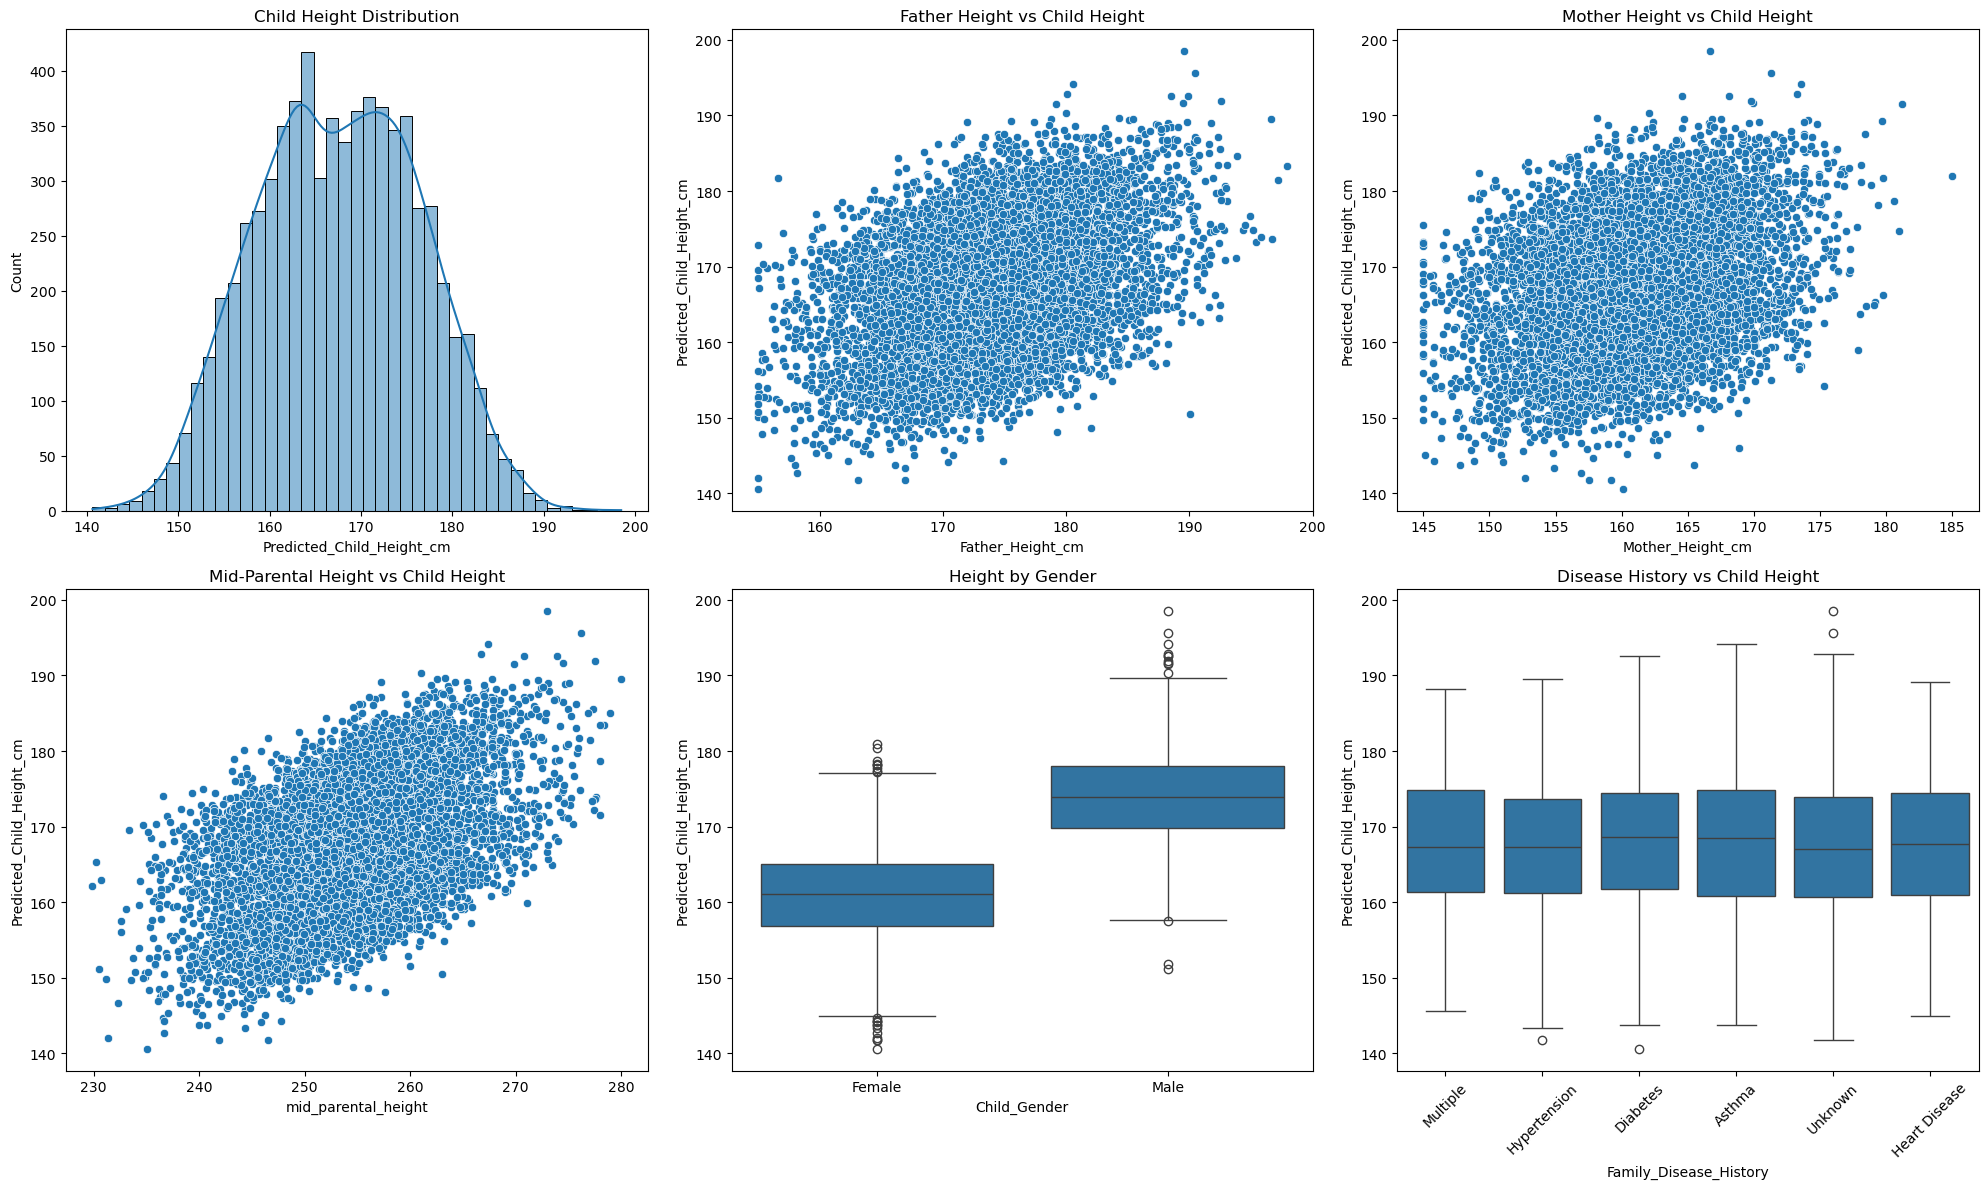

In [ ]:
# Subplots for the columns.

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Target Distribution
sns.histplot(
    df['Predicted_Child_Height_cm'],
    kde=True,
    ax=axes[0, 0]
)
axes[0, 0].set_title('Child Height Distribution')

# 2. Father Height vs Child Height
sns.scatterplot(
    x='Father_Height_cm',
    y='Predicted_Child_Height_cm',
    data=df,
    ax=axes[0, 1]
)
axes[0, 1].set_title('Father Height vs Child Height')

# 3. Mother Height vs Child Height
sns.scatterplot(
    x='Mother_Height_cm',
    y='Predicted_Child_Height_cm',
    data=df,
    ax=axes[0, 2]
)
axes[0, 2].set_title('Mother Height vs Child Height')

# 4. Mid-Parental Height vs Child Height
sns.scatterplot(
    x='mid_parental_height',
    y='Predicted_Child_Height_cm',
    data=df,
    ax=axes[1, 0]
)
axes[1, 0].set_title('Mid-Parental Height vs Child Height')

# 5. Child Height by Gender
sns.boxplot(
    x='Child_Gender',
    y='Predicted_Child_Height_cm',
    data=df,
    ax=axes[1, 1]
)
axes[1, 1].set_title('Height by Gender')

# 6. Disease History vs Child Height
sns.boxplot(
    x='Family_Disease_History',
    y='Predicted_Child_Height_cm',
    data=df,
    ax=axes[1, 2]
)
axes[1, 2].set_title('Disease History vs Child Height')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

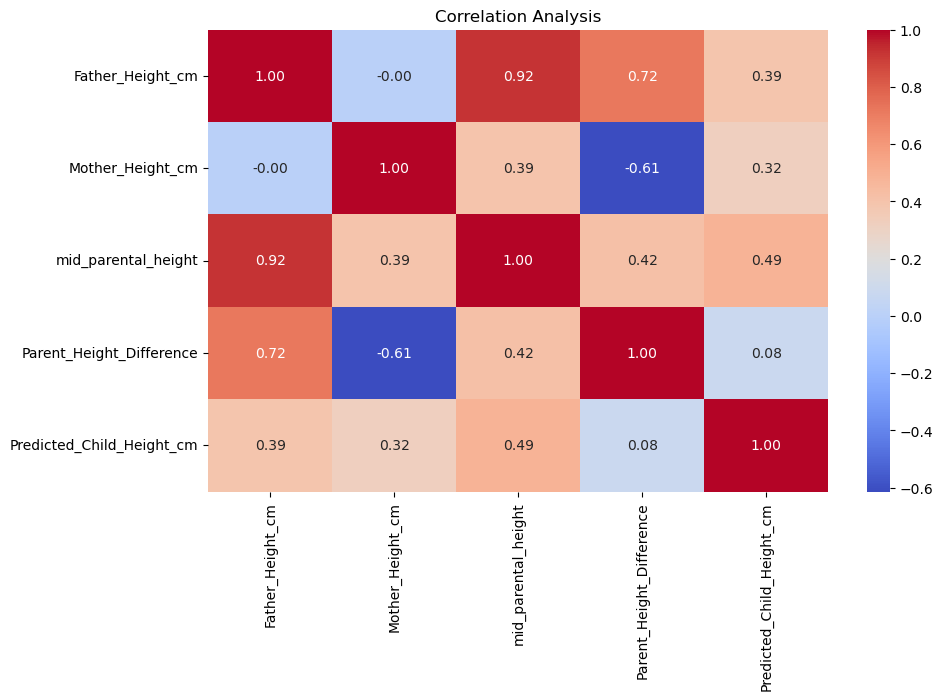

In [ ]:
plt.figure(figsize=(10,6))

corr_cols = [
    'Father_Height_cm',
    'Mother_Height_cm',
    'mid_parental_height',
    'Parent_Height_Difference',
    'Predicted_Child_Height_cm'
]

sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Analysis')
plt.show()

In [ ]:
### Key EDA Insights
"""
The target variable (Predicted_Child_Height_cm) follows an approximately normal distribution with no major outliers.
* Father height and mother height show positive relationships with child height.
* The engineered feature mid_parental_height demonstrates a stronger relationship with child height than either parent's height individually.
* Child gender appears to be an important predictor, with male children showing higher median heights than female children.
* Family disease history shows limited variation across height distributions and may have lower predictive importance.
* Parent_Height_Difference exhibits a weak correlation with child height and may contribute less to model performance.
* Overall, parental heights and child gender appear to be the most informative features for predicting child height."""

" The target variable (Predicted_Child_Height_cm) follows an approximately normal distribution with no major outliers.\n* Father height and mother height show positive relationships with child height.\n* The engineered feature Mid_Parental_Height demonstrates a stronger relationship with child height than either parent's height individually.\n* Child gender appears to be an important predictor, with male children showing higher median heights than female children.\n* Family disease history shows limited variation across height distributions and may have lower predictive importance.\n* Parent_Height_Difference exhibits a weak correlation with child height and may contribute less to model performance.\n* Overall, parental heights and child gender appear to be the most informative features for predicting child height."

In [ ]:
# Features And labeles

X = df.drop(columns=[
    'Predicted_Child_Height_cm',
    'Predicted_Child_Blood_Group',
    'Predicted_Health_Risk'
])
y = df['Predicted_Child_Height_cm']

In [ ]:
X.columns

Index(['Father_Age', 'Mother_Age', 'Father_Height_cm', 'Mother_Height_cm',
       'Father_Blood_Group', 'Mother_Blood_Group', 'Father_Eye_Color',
       'Mother_Eye_Color', 'Father_Hair_Color', 'Mother_Hair_Color',
       'Father_Skin_Tone', 'Mother_Skin_Tone', 'Family_Disease_History',
       'Child_Gender', 'mid_parental_height', 'Parent_Height_Difference',
       'Avg_Parent_Age', 'Parent_Age_Difference'],
      dtype='object')

In [ ]:
print(y.name)
print(y.head())
print(y.dtype)

print(X.shape)
print(X.columns.tolist())



Predicted_Child_Height_cm
0    161.9
1    164.0
2    162.2
3    161.7
4    171.7
Name: Predicted_Child_Height_cm, dtype: float64
float64
(7000, 18)
['Father_Age', 'Mother_Age', 'Father_Height_cm', 'Mother_Height_cm', 'Father_Blood_Group', 'Mother_Blood_Group', 'Father_Eye_Color', 'Mother_Eye_Color', 'Father_Hair_Color', 'Mother_Hair_Color', 'Father_Skin_Tone', 'Mother_Skin_Tone', 'Family_Disease_History', 'Child_Gender', 'mid_parental_height', 'Parent_Height_Difference', 'Avg_Parent_Age', 'Parent_Age_Difference']


In [ ]:
#Numeric and Categorical data changing its respective.

num_cols = X.select_dtypes(
    include=['int64','float64']
).columns

cat_cols = X.select_dtypes(
    include=['object']
).columns

In [ ]:
df.columns

Index(['Father_Age', 'Mother_Age', 'Father_Height_cm', 'Mother_Height_cm',
       'Father_Blood_Group', 'Mother_Blood_Group', 'Father_Eye_Color',
       'Mother_Eye_Color', 'Father_Hair_Color', 'Mother_Hair_Color',
       'Father_Skin_Tone', 'Mother_Skin_Tone', 'Family_Disease_History',
       'Child_Gender', 'Predicted_Child_Blood_Group', 'Predicted_Health_Risk',
       'Predicted_Child_Height_cm', 'mid_parental_height',
       'Parent_Height_Difference', 'Avg_Parent_Age', 'Parent_Age_Difference'],
      dtype='object')

In [ ]:
# Splitting the train test split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
#Create ColumnTransformer

# Numeric using scaler
num_transformer = StandardScaler()

#Categorical Encoder

cat_transformer = OneHotEncoder(handle_unknown='ignore')


In [ ]:
# combining both Numeric and Categorical columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(),num_cols)
    ],
    remainder='passthrough'
)

In [ ]:
# Creating a Model Slection Algorihthm

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42, max_depth=5, min_samples_split=10),
    "Decision Tree": DecisionTreeRegressor(random_state=42, max_depth=5, min_samples_split=10),
    "Ridge" : Ridge(alpha=0.5),
    "Lasso" : Lasso(alpha=0.1),
    "Kneigh" : KNeighborsRegressor()
}


In [ ]:
def evaluate_models(models):

    results = []

    for name, model in models.items():

        pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])

        # Fit model
        pipe.fit(X_train, y_train)

        # Scores
        train_score = pipe.score(X_train, y_train)
        test_score = pipe.score(X_test, y_test)

        results.append({
            "Model": name,
            "Train score": train_score,
            "Test score": test_score
        })

    return pd.DataFrame(results)

In [ ]:
scores = evaluate_models(models)
print(scores)

               Model  Train score  Test score
0  Linear Regression     0.796782    0.776863
1      Random Forest     0.802968    0.772300
2      Decision Tree     0.792925    0.754300
3              Ridge     0.796782    0.776877
4              Lasso     0.794254    0.779963
5             Kneigh     0.751003    0.624450


In [ ]:
### Model Comparison Insights

"""* Multiple regression models were evaluated, including Linear Regression, Ridge, Lasso, Random Forest, Decision Tree, and K-Nearest Neighbors.
* Linear Regression and Lasso Regression achieved the strongest overall performance on the test dataset.
* Linear Regression produced a test R² score of approximately 0.79 while maintaining a very small gap between training and testing performance.
* Random Forest and Decision Tree models did not provide meaningful improvements over Linear Regression.
* K-Nearest Neighbors performed poorly, indicating that local similarity-based prediction is not well suited for this dataset.
* Due to its strong performance, simplicity, interpretability, and low risk of overfitting, Linear Regression was selected as the final model"""

'* Multiple regression models were evaluated, including Linear Regression, Ridge, Lasso, Random Forest, Decision Tree, and K-Nearest Neighbors.\n* Linear Regression and Lasso Regression achieved the strongest overall performance on the test dataset.\n* Linear Regression produced a test R² score of approximately 0.78 while maintaining a very small gap between training and testing performance.\n* Random Forest and Decision Tree models did not provide meaningful improvements over Linear Regression.\n* K-Nearest Neighbors performed poorly, indicating that local similarity-based prediction is not well suited for this dataset.\n* Due to its strong performance, simplicity, interpretability, and low risk of overfitting, Linear Regression was selected as the final model'

In [ ]:
best_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

best_pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
# Checking the cross val score

cv = cross_val_score(best_pipe, X_train, y_train, scoring='r2')

print("Cross Val Score", cv)
print("Mean of Cv", cv.mean())

Cross Val Score [0.80428947 0.78880687 0.78880716 0.79421531 0.78726518]
Mean of Cv 0.7926767953084799


In [ ]:
### Cross Validation Insights

"""
* The model achieved a mean cross-validation R² score of **0.79**.
* Cross-validation scores were consistent across all folds.
* The CV score closely matches the test R² score, indicating good generalization.
* The model shows no significant signs of overfitting or underfitting.
* Overall, Linear Regression demonstrates stable and reliable performance on unseen data."""


In [ ]:
# Prediction for model

y_pred = best_pipe.predict(X_test)

In [ ]:
# Checking the matrcies 

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)   
rmse = np.sqrt(mse)

print("MSE", mse)
print("MAE", mae)
print("R2", r2)
print("Rmse", rmse)

MSE 16.174804860700085
MAE 3.171141712079186
R2 0.7768631394111835
Rmse 4.021791250264002


In [ ]:
### Model Evaluation Insights
"""
* The Linear Regression model achieved an R² score of **0.77**, explaining approximately 77.7% of the variance in child height.
* The model achieved an MAE of **3.17 cm**, indicating low average prediction error.
* RMSE of **4.02 cm** suggests the model makes reasonably accurate predictions with no major error spikes.
* Overall, the model demonstrates strong predictive performance and good generalization ability."""


'\n* The Linear Regression model achieved an R² score of **0.78**, explaining approximately 77.7% of the variance in child height.\n* The model achieved an MAE of **3.17 cm**, indicating low average prediction error.\n* RMSE of **4.02 cm** suggests the model makes reasonably accurate predictions with no major error spikes.\n* Overall, the model demonstrates strong predictive performance and good generalization ability.'

In [ ]:
# Residual Analysis

residuals = y_test - y_pred
print(residuals)

6500   -1.608141
2944   -5.074382
2024    4.135328
263     2.793997
4350   -1.193217
          ...   
3484    1.425004
1860   -0.085469
4974   -1.595930
387    -2.533232
4336   -1.541404
Name: Predicted_Child_Height_cm, Length: 1400, dtype: float64


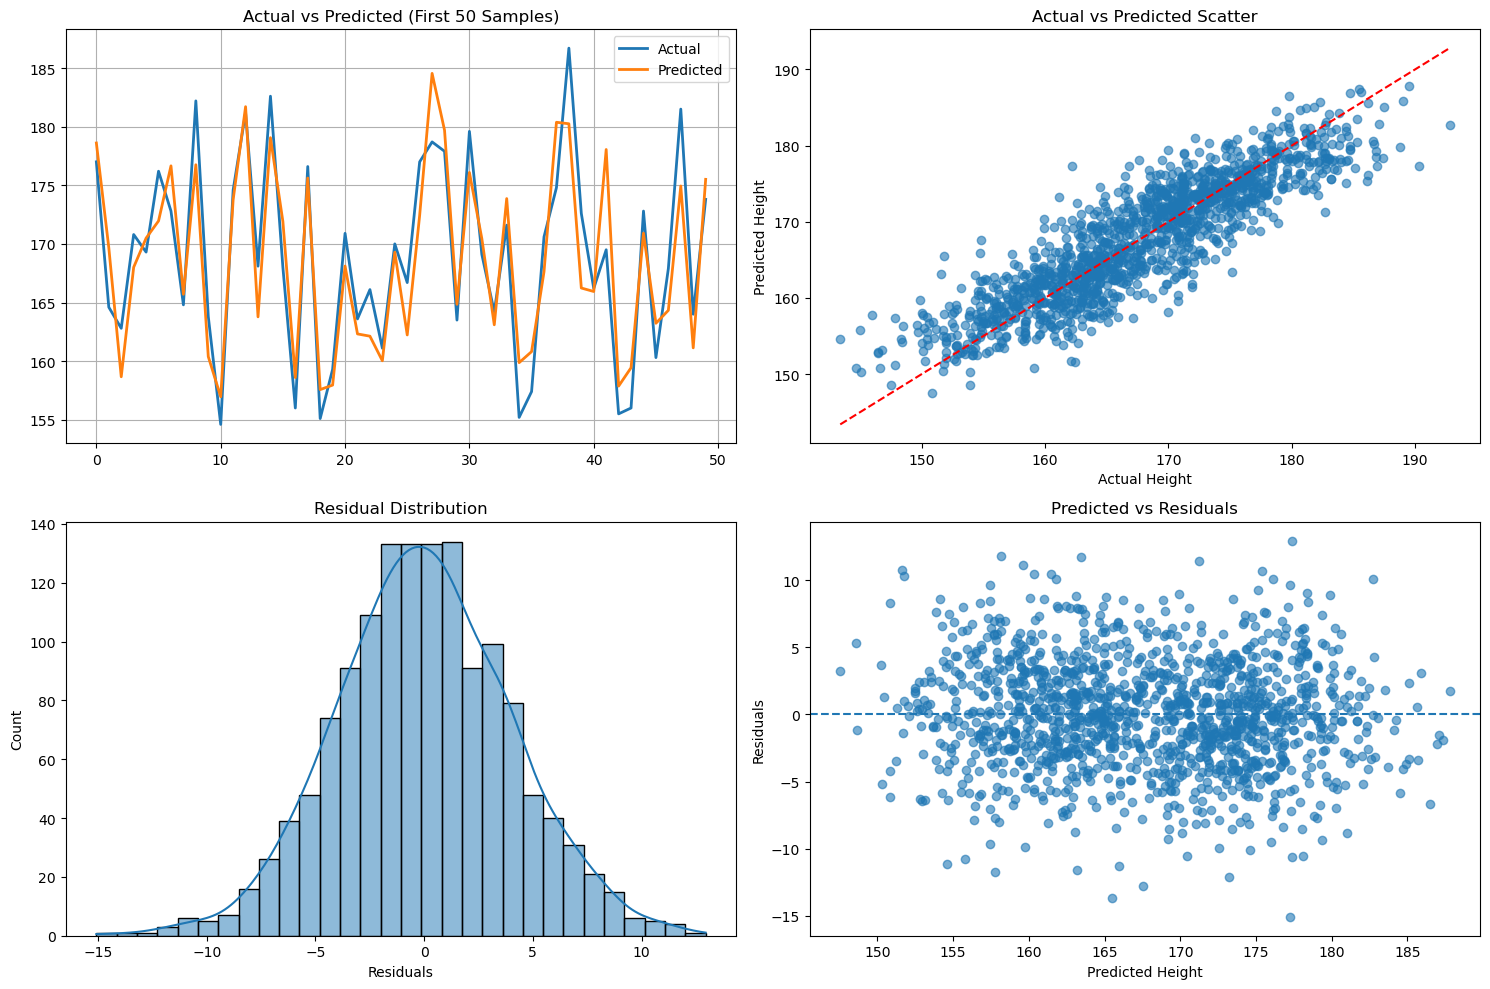

In [ ]:
residuals = y_test - y_pred

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Actual vs Predicted Line Plot
axes[0,0].plot(
    y_test.values[:50],
    label='Actual',
    linewidth=2
)

axes[0,0].plot(
    y_pred[:50],
    label='Predicted',
    linewidth=2
)

axes[0,0].set_title('Actual vs Predicted (First 50 Samples)')
axes[0,0].legend()
axes[0,0].grid(True)

# 2. Actual vs Predicted Scatter Plot
axes[0,1].scatter(
    y_test,
    y_pred,
    alpha=0.6
)

axes[0,1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

axes[0,1].set_title('Actual vs Predicted Scatter')
axes[0,1].set_xlabel('Actual Height')
axes[0,1].set_ylabel('Predicted Height')

# 3. Residual Distribution
sns.histplot(
    residuals,
    kde=True,
    ax=axes[1,0]
)

axes[1,0].set_title('Residual Distribution')
axes[1,0].set_xlabel('Residuals')

# 4. Predicted vs Residuals
axes[1,1].scatter(
    y_pred,
    residuals,
    alpha=0.6
)

axes[1,1].axhline(
    y=0,
    linestyle='--'
)

axes[1,1].set_title('Predicted vs Residuals')
axes[1,1].set_xlabel('Predicted Height')
axes[1,1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

In [ ]:
### Model Diagnostic Insights
"""
* Predicted values closely align with actual child heights.
* The scatter plot shows observations concentrated around the ideal prediction line.
* Residuals are approximately centered around zero and follow a near-normal distribution.
* No clear pattern is observed in the residual scatter plot, indicating that the Linear Regression model captures the underlying relationships effectively."""


'\n* Predicted values closely align with actual child heights.\n* The scatter plot shows observations concentrated around the ideal prediction line.\n* Residuals are approximately centered around zero and follow a near-normal distribution.\n* No clear pattern is observed in the residual scatter plot, indicating that the Linear Regression model captures the underlying relationships effectively.'

In [ ]:
feature_names = best_pipe.named_steps[
    'preprocessor'
].get_feature_names_out()

In [ ]:
coef = best_pipe.named_steps[
    'model'
].coef_

In [ ]:
coef_df = pd.DataFrame({
    'Feature' : feature_names,
    'Coefficents' : coef
})

coef_df.sort_values(
    by='Coefficents',
    ascending=False
).head(15)

,Feature,Coefficents
51,cat__Child_Gender_Male,6.497931
56,num__mid_parental_height,2.185979
55,num__Mother_Height_cm,1.924782
54,num__Father_Height_cm,1.544741
3,cat__Father_Blood_Group_AB-,0.846943
15,cat__Mother_Blood_Group_O-,0.484022
5,cat__Father_Blood_Group_B-,0.380026
9,cat__Mother_Blood_Group_A-,0.246439
23,cat__Mother_Eye_Color_Gray,0.183884
42,cat__Mother_Skin_Tone_Medium,0.171472


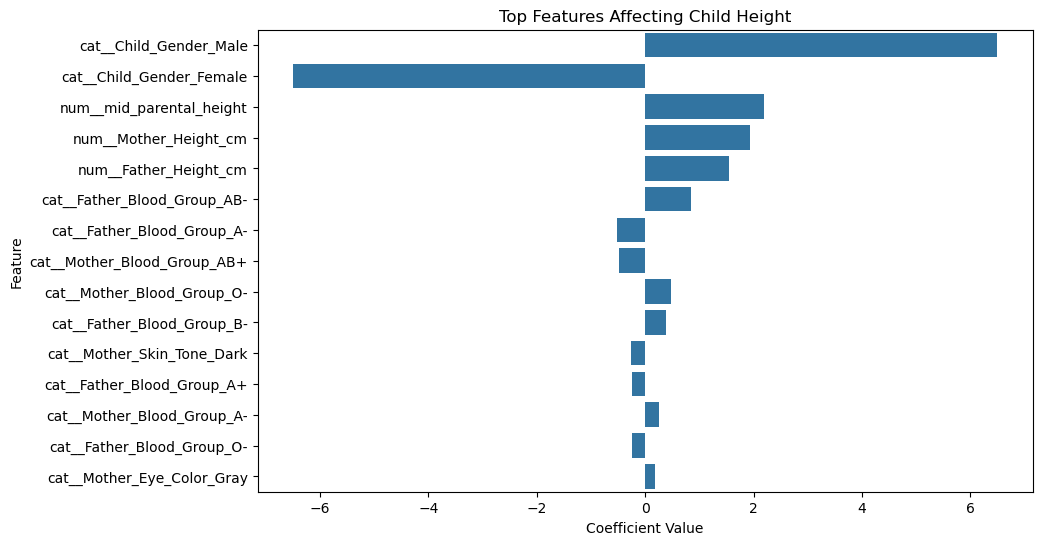

In [ ]:
top_features = coef_df.reindex(
    coef_df['Coefficents'].abs().sort_values(ascending=False).index
).head(15)


plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x='Coefficents',
    y='Feature'
)

plt.title('Top Features Affecting Child Height')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')

plt.show()



In [ ]:
### Feature Importance Insights

"""
- Child gender emerged as the strongest predictor of child height.
- The engineered feature Mid_Parental_Height was among the most influential features, validating the feature engineering process.
- Both father and mother heights contributed positively to height prediction.
- Family disease history features showed relatively small effects on child height.
- Overall, parental physical characteristics and child gender were the key drivers of model predictions."""

In [ ]:
# Final Conclusion.
""""
- Successfully developed a machine learning regression model to predict child height using parental genetic and physical characteristics.
- Performed data cleaning, missing value handling, feature engineering, and exploratory data analysis.
- Created domain-based features such as Mid_Parental_Height, Parent_Height_Difference, Avg_Parent_Age, and Parent_Age_Difference.
- Linear Regression was selected as the final model due to its strong performance, interpretability, and stable generalization.
- The model achieved an R2 score of 0.78 and a Cross-Validation R2 score of 0.79, indicating reliable predictive performance.
- Child gender and parental height-related features emerged as the most influential predictors.
- Feature engineering improved the model's ability to capture genetic influences on child height.
- Overall, the project demonstrates a complete end-to-end machine learning workflow from data preprocessing to model interpretation."""

In [ ]:
# Step 1: Save the trained pipeline to disk

os.makedirs("models", exist_ok=True)

joblib.dump(best_pipe, "models/child_height_model.pkl")

print("Model saved successfully at: models/child_height_model.pkl")

In [ ]:
# Step 2: Load the saved model back from disk

loaded_model = joblib.load("models/child_height_model.pkl")

print("Model loaded successfully.")
print(loaded_model)

In [ ]:
# Step 3: Verify loaded model gives same predictions as best_pipe

sample = X_test.iloc[[0]]

pred_loaded = loaded_model.predict(sample)
pred_original = best_pipe.predict(sample)

print("Prediction from loaded model :", pred_loaded)
print("Prediction from best_pipe    :", pred_original)
print("Match:", round(pred_loaded[0], 4) == round(pred_original[0], 4))

In [ ]:
### Model Persistence

"""
- The final trained Linear Regression pipeline (preprocessor + model) was saved
  using joblib to 'models/child_height_model.pkl'.
- The saved model was successfully reloaded and verified to produce identical
  predictions to the original pipeline.
- This allows the model to be reused for future predictions without retraining.
"""